# Natural Language Processing



This project will give you practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) you will use a dataset in a CSV file
- in part 2) you will use the Wikipedia API to directly access content
on Wikipedia.
- in part 3) you will make your notebook interactive


### Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



### Part 2)



- For the same reference person that you chose in Part 1), use the Wikipedia API to access the whole content of the reference person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the reference person
  1. Determine the sentiment of the text of the Wikipedia page for the reference person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



### Part 3)


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


In [1]:
%%capture output
#install Wikipedia API
!pip3 install wikipedia-api


In [2]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import nltk
# nltk.download('omw-1.4')
nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')

import wikipediaapi

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [4]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


In [5]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n


     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

In [6]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'

In [7]:
data = pd.read_csv(url)

In [8]:
data

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


In [9]:
data_c = data.copy()

## Part 1

In [10]:
data_c.drop( columns = ['URI'])

,name,text
0,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...
42781,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


In [11]:
# I want to singularize "born"
# later I will compare who has is closer is age by trying to figure out how to single out birth date


In [12]:
# i would like to just begin with a smaller range of data to start light and build

In [73]:
data_c

,URI,name,text,cleaned_text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...,henry krvit born 30 december 1974 in tallinn b...
5,<http://dbpedia.org/resource/Sam_Henderson>,Sam Henderson,sam henderson born october 18 1969 is an ameri...,sam henderson born october 18 1969 is an ameri...
6,<http://dbpedia.org/resource/Aaron_LaCrate>,Aaron LaCrate,aaron lacrate is an american music producer re...,aaron lacrate is an american music producer re...
7,<http://dbpedia.org/resource/Trevor_Ferguson>,Trevor Ferguson,trevor ferguson aka john farrow born 11 novemb...,trevor ferguson aka john farrow born 11 novemb...
8,<http://dbpedia.org/resource/Grant_Nelson>,Grant Nelson,grant nelson born 27 april 1971 in london also...,grant nelson born 27 april 1971 in london also...
9,<http://dbpedia.org/resource/Cathy_Caruth>,Cathy Caruth,cathy caruth born 1955 is frank h t rhodes pro...,cathy caruth born 1955 is frank h t rhode prof...


In [15]:
print(data_c.loc[0, 'text'])

digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play victorian football league vfl football with the northern bullants carltons vflaf

## cleaning

In [16]:
# 1. Access index 0 using .loc[index, 'column_name']
sentence_0_tb = TextBlob(data_c.loc[0, 'text'])
sentence_0_singular = [x.singularize() for x in sentence_0_tb.words]
sentence_0_clean = ' '.join(sentence_0_singular)

In [17]:
sentence_0_clean

'digby morrell born 10 october 1979 is a former australian rule footballer who played with the kangaroo and carlton in the australian football league aflfrom western australium morrell played hi early senior football for west perth hi 44game senior career for the falcon spanned 19982000 and he wa the club leading goalkicker in 2000 at the age of 21 morrell wa recruited to the australian football league by the kangaroo football club with it third round selection in the 2001 afl rookie draft a a forward he twice kicked five goal during hi time with the kangaroo the first wa in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell wa traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 game for the blue before being delisted at the end of 2005 he continued to play victorian football league vfl football with the northern bullant carlton vflaffiliate in 2006 an

In [18]:
# must find a way to loop and clean the 20 rows that I have to minimize the number of nique characters that are practically the same
# Create an empty list to store our cleaned sentences
cleaned_list = []

# Loop through every row in your light dataset
for text in data_c['text']:
    # 1. Turn the text row into a TextBlob object
    tb = TextBlob(text)

    # 2. Singularize every word in that blob
    singular_words = [x.singularize() for x in tb.words]

    # 3. Join the words back together into a single string
    clean_sentence = ' '.join(singular_words)

    # 4. Append the clean string to our list
    cleaned_list.append(clean_sentence)

# Add the list as a new column in your DataFrame
data_c['cleaned_text'] = cleaned_list

# View the result
data_c[['name', 'cleaned_text']].head()

,name,cleaned_text
0,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,G-Enka,henry krvit born 30 december 1974 in tallinn b...


In [19]:
# 1. Initialize the CountVectorizer (ignores common stop words)
vectorizer = CountVectorizer(stop_words='english')

# 2. Fit and transform your newly cleaned text column
bag_of_words = vectorizer.fit_transform(data_c['cleaned_text'])

# 3. Convert it into a clean, readable DataFrame to see the counts
bow_df = pd.DataFrame(
    bag_of_words.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=data_c['name']
)

# View the word count table
bow_df.head()

,10,1000,102,11,12,1406,17,173182,17th,18,...,yale,year,york,yorksince,young,youngest,zarathustra,zelazny,ziet,zwigoff
name,,,,,,,,,,,,,,,,,,,,,
Digby Morrell,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alfred J. Lewy,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Harpdog Brown,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
Franz Rottensteiner,0,0,0,0,0,0,0,0,0,1,...,0,4,1,0,0,0,0,1,0,0
G-Enka,0,0,0,0,0,0,0,0,0,1,...,0,2,0,0,0,0,0,0,0,0


## TF-IDF

In [20]:
# 1. Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# 2. Fit and transform your cleaned text
tfidf_matrix = tfidf_vectorizer.fit_transform(data_c['cleaned_text'])

# 3. Convert it into a readable DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=data_c['name']
)

# View the TF-IDF table
tfidf_df.head()

,10,1000,102,11,12,1406,17,173182,17th,18,...,yale,year,york,yorksince,young,youngest,zarathustra,zelazny,ziet,zwigoff
name,,,,,,,,,,,,,,,,,,,,,
Digby Morrell,0.043715,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
Alfred J. Lewy,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
Harpdog Brown,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.083337,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
Franz Rottensteiner,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.046996,...,0.0,0.131622,0.039951,0.0,0.0,0.0,0.0,0.059039,0.0,0.0
G-Enka,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.051197,...,0.0,0.071695,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [21]:
tf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=data_c['name']
)

# Check the shape of the DataFrame
tf_df.shape

(21, 1954)

In [22]:
tf_df

,10,1000,102,11,12,1406,17,173182,17th,18,...,yale,year,york,yorksince,young,youngest,zarathustra,zelazny,ziet,zwigoff
name,,,,,,,,,,,,,,,,,,,,,
Digby Morrell,0.043715,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Alfred J. Lewy,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Harpdog Brown,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.0000,0.083337,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Franz Rottensteiner,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.046996,...,0.0000,0.131622,0.039951,0.000000,0.000000,0.000000,0.000000,0.059039,0.000000,0.000000
G-Enka,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.051197,...,0.0000,0.071695,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sam Henderson,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.048578,...,0.0000,0.034013,0.123887,0.061027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aaron LaCrate,0.027488,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.0000,0.000000,0.025468,0.000000,0.033146,0.037637,0.000000,0.000000,0.000000,0.000000
Trevor Ferguson,0.000000,0.041802,0.000000,0.041802,0.000000,0.000000,0.041802,0.00000,0.000000,0.000000,...,0.0000,0.023299,0.084860,0.000000,0.000000,0.000000,0.041802,0.000000,0.041802,0.000000
Grant Nelson,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [23]:
df = pd.DataFrame(
    tfidf_matrix[3].T.todense(),
    index=tfidf_vectorizer.get_feature_names_out(),
    columns=["TF-IDF"]
)

# Sort words by highest TF-IDF score
df = df.sort_values('TF-IDF', ascending=False)

# Display top words
df.head(10)

,TF-IDF
fiction,0.328969
science,0.239703
lem,0.236157
rottensteiner,0.177117
book,0.172474
number,0.155982
author,0.140987
year,0.131622
1975,0.118078
austrium,0.118078


In [24]:
filtered_df = data_c[
    data_c['text'].str.contains('fiction')
 #   data_c['text'].str.contains('science') &
 #   data_c['text'].str.contains('lem')
]

filtered_df

,URI,name,text,cleaned_text
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...,franz rottensteiner born in waidmannsfeld lowe...
7,<http://dbpedia.org/resource/Trevor_Ferguson>,Trevor Ferguson,trevor ferguson aka john farrow born 11 novemb...,trevor ferguson aka john farrow born 11 novemb...
9,<http://dbpedia.org/resource/Cathy_Caruth>,Cathy Caruth,cathy caruth born 1955 is frank h t rhodes pro...,cathy caruth born 1955 is frank h t rhode prof...
15,<http://dbpedia.org/resource/Joerg_Steineck>,Joerg Steineck,joerg steineck is a german filmmaker editor an...,joerg steineck is a german filmmaker editor an...


# Euclidean


In [25]:
# 1. Initialize NearestNeighbors using Euclidean distance
nn_euclidean = NearestNeighbors(n_neighbors=11, metric='euclidean')

# 2. Fit the model on your TF-IDF matrix
nn_euclidean.fit(tfidf_matrix)

# 3. Find the index for 'Digby Morrell'
digby_index = data_c[data_c['name'] == 'Digby Morrell'].index[0]

# 4. Get the distances and indices of the 11 nearest neighbors
distances, indices = nn_euclidean.kneighbors(tfidf_matrix[digby_index])

# 5. Display the top 10 closest people (excluding Digby himself at index 0)
closest_indices = indices[0][1:]
closest_people = data_c.iloc[closest_indices][['name', 'text']]

# Optional: Add the Euclidean distance column to see the exact distance values
closest_people['distance'] = distances[0][1:]

closest_people

,name,text,distance
17,Paddy Dunne (Gaelic footballer),paddy dunne was a gaelic football player from ...,1.217086
2,Harpdog Brown,harpdog brown is a singer and harmonica player...,1.366073
7,Trevor Ferguson,trevor ferguson aka john farrow born 11 novemb...,1.376787
19,John Angus Campbell,john angus campbell born march 10 1942 in port...,1.386483
14,David Chernushenko,david chernushenko born june 1963 in calgary a...,1.386620
6,Aaron LaCrate,aaron lacrate is an american music producer re...,1.387208
8,Grant Nelson,grant nelson born 27 april 1971 in london also...,1.393674
5,Sam Henderson,sam henderson born october 18 1969 is an ameri...,1.395155
11,Jenn Ashworth,jenn ashworth is an english writer she was bor...,1.395384
3,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...,1.396444


# Part 1 larger scale

In [26]:
data_c2 = data.copy()

In [27]:
# I decided not to drop URI because i will need it for part 2
data_c2.shape

(42786, 3)

In [28]:
halfway_point = len(data_c2) // 2
data_c2 = data_c2.drop(data_c2.index[halfway_point:])

In [29]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(data_c2['text'])

In [30]:
sentence_0_tb2 = TextBlob(data_c2.loc[0, 'text'])
sentence_0_singular2 = [x.singularize() for x in sentence_0_tb2.words]
sentence_0_clean2 = ' '.join(sentence_0_singular2)

In [31]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Define a fast function using regular expressions
def remove_fillers(text):
    # Keep only letters and spaces, convert to lowercase, split into words
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    # Filter out stop words
    filtered_words = [w for w in words if w not in stop_words]
    return ' '.join(filtered_words)

# Apply efficiently across the DataFrame column
data_c2['cleaned_text'] = data_c2['text'].apply(remove_fillers)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
# Lemmatizer turning synanoms to the basic vocab word
import nltk
from nltk.stem import WordNetLemmatizer

# Download the WordNet dataset (required for the lemmatizer to work)
nltk.download('wordnet')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()
words = text.lower().split()

cleaned_words = [lemmatizer.lemmatize(w) for w in words]
cleaned_text = ' '.join(cleaned_words)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [33]:
# the previous two cells can be made simpler by the following code
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Lowercase & Split
    words = str(text).lower().split()

    # 2. Filter stop words & Lemmatize
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    # 3. Join back to string
    return ' '.join(cleaned)

# Apply across DataFrame
data_c2['cleaned_text'] = data_c2['text'].apply(clean_text)

In [34]:
data_c2

,URI,name,text,cleaned_text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...,digby morrell born 10 october 1979 former aust...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...,alfred j lewy aka sandy lewy graduated univers...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...,harpdog brown singer harmonica player active c...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...,franz rottensteiner born waidmannsfeld lower a...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...,henry krvits born 30 december 1974 tallinn bet...
...,...,...,...,...
21388,<http://dbpedia.org/resource/Ned_Hastings>,Ned Hastings,ned hastings born august 26 1966 in atlanta ge...,ned hastings born august 26 1966 atlanta georg...
21389,<http://dbpedia.org/resource/Percy_Paris>,Percy Paris,percy a paris is a former canadian politician ...,percy paris former canadian politician nova sc...
21390,<http://dbpedia.org/resource/MD&C_Pavlov>,MD&C Pavlov,alexey vladimirovich pavlov russian born 8 feb...,alexey vladimirovich pavlov russian born 8 feb...
21391,<http://dbpedia.org/resource/Artyom_Melikhov>,Artyom Melikhov,artyom melikhov is a russian tenor singer who ...,artyom melikhov russian tenor singer born sain...


In [35]:
# I want to keep lowering the info that I have to be able to run the code. I will now be focusing on names column
# want to drop rows that have names that have any character other than letters

non_letter_rows = data_c2[data_c2['name'].str.contains(r'[^a-zA-Z\s().,-]', regex=True, na=False)]
non_letter_rows

,URI,name,text,cleaned_text
13,<http://dbpedia.org/resource/Anthony_Gueterboc...,"Anthony Gueterbock, 18th Baron Berkeley",anthony fitzhardinge gueterbock 18th baron ber...,anthony fitzhardinge gueterbock 18th baron ber...
35,<http://dbpedia.org/resource/Freimut_B%C3%B6rn...,Freimut B%C3%B6rngen,freimut brngen born october 17 1930 is a germa...,freimut brngen born october 17 1930 german ast...
36,<http://dbpedia.org/resource/Th%C3%BCring_Br%C...,Th%C3%BCring Br%C3%A4m,thring brm born 10 april 1944 is a swiss compo...,thring brm born 10 april 1944 swiss composer c...
73,<http://dbpedia.org/resource/Marcel_J._Melan%C...,Marcel J. Melan%C3%A7on,marcel j mlanon is a philosopher and scientist...,marcel j mlanon philosopher scientist work can...
85,<http://dbpedia.org/resource/Zvonimir_Juri%C4%87>,Zvonimir Juri%C4%87,zvonimir juri born 4 june 1971 is a croatian f...,zvonimir juri born 4 june 1971 croatian film d...
...,...,...,...,...
21319,<http://dbpedia.org/resource/Frank_'Bluey'_Adams>,Frank 'Bluey' Adams,frank bluey adams born 12 june 1935 is a forme...,frank bluey adam born 12 june 1935 former aust...
21324,<http://dbpedia.org/resource/Stuart_Roberts_(f...,"Stuart Roberts (footballer, born 1980)",stuart roberts born 22 july 1980 in carmarthen...,stuart robert born 22 july 1980 carmarthen wel...
21370,<http://dbpedia.org/resource/Carola_H%C3%A4ggk...,Carola H%C3%A4ggkvist,carola maria hggkvist swedish pronunciation ka...,carola maria hggkvist swedish pronunciation ka...
21376,<http://dbpedia.org/resource/%C3%81lvaro_Rudol...,%C3%81lvaro Rudolphy,lvaro gonzalo rudolphy fontaine born may 24 19...,lvaro gonzalo rudolphy fontaine born may 24 19...


In [36]:
data_c2.shape

(21393, 4)

In [37]:
data_c2 = data_c2[~data_c2['name'].str.contains(r'[^a-zA-Z\s().,-]', regex=True, na=False)].reset_index(drop=True)

In [38]:
data_c2.shape

(19882, 4)

In [39]:
data_c2.drop(columns = [ 'text'])

,URI,name,cleaned_text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 former aust...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated univers...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown singer harmonica player active c...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born waidmannsfeld lower a...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 tallinn bet...
...,...,...,...
19877,<http://dbpedia.org/resource/Henryk_Skolimowski>,Henryk Skolimowski,henryk skolimowski born 1930 warsaw polish phi...
19878,<http://dbpedia.org/resource/Ned_Hastings>,Ned Hastings,ned hastings born august 26 1966 atlanta georg...
19879,<http://dbpedia.org/resource/Percy_Paris>,Percy Paris,percy paris former canadian politician nova sc...
19880,<http://dbpedia.org/resource/Artyom_Melikhov>,Artyom Melikhov,artyom melikhov russian tenor singer born sain...


In [40]:
# now with a somewhat clean large set of data I will now pick Dibgy Morrel and find which names are the 10 closest in text
# 1. Initialize CountVectorizer
vectorizer = CountVectorizer(min_df=100, stop_words='english')

# 2. Fit and transform your cleaned text column
bow_matrix = vectorizer.fit_transform(data_c2['cleaned_text'])

# 3. Convert to a Pandas DataFrame for easy viewing
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=data_c2['name'],

)

# Preview the Bag-of-Words matrix
bow_df.head()

,10,100,1000,10000,10th,11,11th,12,12th,13,...,york,yorker,yorkshire,young,younger,youngest,youth,youtube,zealand,zone
name,,,,,,,,,,,,,,,,,,,,,
Digby Morrell,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alfred J. Lewy,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Harpdog Brown,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Franz Rottensteiner,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
G-Enka,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
tf_idf_matrix = TfidfTransformer()
tf_idf_data_c2 = tf_idf_matrix.fit_transform(bow_matrix)


In [42]:
# trying to figure out the neighbors
nn = NearestNeighbors().fit(tf_idf_data_c2)


In [43]:
# I chose Digby Morrell. he is in index 0
sent0 = tf_idf_data_c2[0]
sent0.shape


(1, 3775)

In [44]:
# making the matrix. want to find the 10 people closest to him
distances, indices = nn.kneighbors(
  X = sent0,
  n_neighbors = 10,
)


In [45]:
distances

array([[0.        , 0.81140725, 0.86003139, 0.8863668 , 0.89931246,
        0.89989502, 0.90090948, 0.90925143, 0.90970699, 0.92237871]])

In [46]:
indices

array([[    0, 16091,  5705,  3553, 15371,  1258,   747,  4228, 15501,
        19844]])

In [47]:
#these are the people close to Digby morrel

In [48]:
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), start=1):
    person_name = data_c2.iloc[idx]['name']
    print(f"{rank}. Index {idx:5d} | Distance: {dist:.4f} | Name: {person_name}")

1. Index     0 | Distance: 0.0000 | Name: Digby Morrell
2. Index 16091 | Distance: 0.8114 | Name: Simon Eastaugh
3. Index  5705 | Distance: 0.8600 | Name: Richard Ambrose
4. Index  3553 | Distance: 0.8864 | Name: Clayton Collard
5. Index 15371 | Distance: 0.8993 | Name: Maurie Fowler
6. Index  1258 | Distance: 0.8999 | Name: Lindsay Smith (Australian footballer)
7. Index   747 | Distance: 0.9009 | Name: David Ellard
8. Index  4228 | Distance: 0.9093 | Name: Jaryd Cachia
9. Index 15501 | Distance: 0.9097 | Name: Adam Iacobucci
10. Index 19844 | Distance: 0.9224 | Name: Darren Pfeiffer


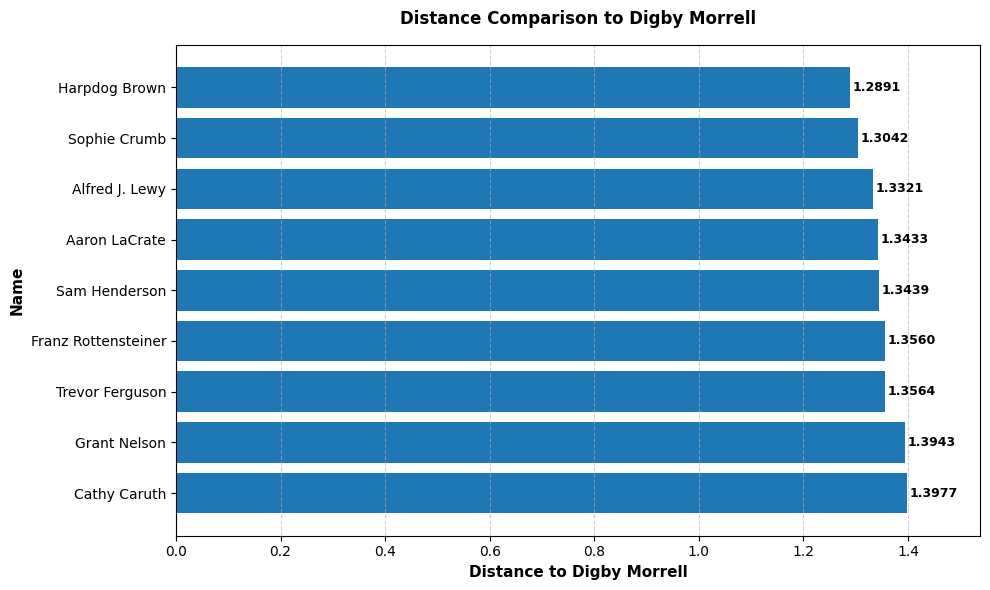

In [99]:
import matplotlib.pyplot as plt

# 1. Gather names and distances from your loop (excluding index 0 / Digby Morrell)
names = []
dists = []

for idx, dist in zip(indices[0][1:], distances[0][1:]):
    names.append(data_c2.iloc[idx]['name'])
    dists.append(dist)

# 2. Reverse lists so the nearest neighbor (Rank 1) appears at the top of the chart
names.reverse()
dists.reverse()

# 3. Create the plot
plt.figure(figsize=(10, 6))
bars = plt.barh(names, dists, color='#1f77b4')

# 4. Add exact distance values on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center',
        ha='left',
        fontsize=9,
        fontweight='bold'
    )

# 5. Formatting
plt.xlabel('Distance to Digby Morrell', fontsize=11, fontweight='bold')
plt.ylabel('Name', fontsize=11, fontweight='bold')
plt.title('Distance Comparison to Digby Morrell', fontsize=12, fontweight='bold', pad=15)

# Set x-axis limit slightly higher to leave room for text labels
plt.xlim(0, max(dists) * 1.1)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Part 2 - Wikipedia

In [50]:
%%capture
!pip3 install wikipedia-api


In [51]:
import wikipediaapi

In [52]:
# Select the 10 closest rows and include URI, name, and distance
results_df = data_c2.iloc[indices[0]][['name', 'URI']].copy()
results_df['distance'] = distances[0]

# Reorder columns for readability
results_df = results_df[['name', 'distance', 'URI']]
results_df

,name,distance,URI
0,Digby Morrell,0.000000,<http://dbpedia.org/resource/Digby_Morrell>
16091,Simon Eastaugh,0.811407,<http://dbpedia.org/resource/Simon_Eastaugh>
5705,Richard Ambrose,0.860031,<http://dbpedia.org/resource/Richard_Ambrose>
3553,Clayton Collard,0.886367,<http://dbpedia.org/resource/Clayton_Collard>
15371,Maurie Fowler,0.899312,<http://dbpedia.org/resource/Maurie_Fowler>
1258,Lindsay Smith (Australian footballer),0.899895,<http://dbpedia.org/resource/Lindsay_Smith_(Au...
747,David Ellard,0.900909,<http://dbpedia.org/resource/David_Ellard>
4228,Jaryd Cachia,0.909251,<http://dbpedia.org/resource/Jaryd_Cachia>
15501,Adam Iacobucci,0.909707,<http://dbpedia.org/resource/Adam_Iacobucci>
19844,Darren Pfeiffer,0.922379,<http://dbpedia.org/resource/Darren_Pfeiffer>


In [53]:
#http://dbpedia.org/resource/Digby_Morrell
topic = 'Digby Morrell'
wikip = wikipediaapi.Wikipedia('foobar')
page_ex = wikip.page(topic)
wiki_text = page_ex.text
wiki_text

"Digby Morrell (born 10 October 1979) is a former Australian rules footballer who played with the Kangaroos and Carlton in the Australian Football League (AFL).\nFrom Western Australia, Morrell played his early senior football for West Perth. His 44-game senior career for the Falcons spanned 1998–2000, and he was the club's leading goalkicker in 2000. At the age of 21, Morrell was recruited to the Australian Football League by the North Melbourne Football Club with its third round selection in the 2001 AFL Rookie Draft. As a forward he twice kicked five goals during his time with the Kangaroos. The first was in a losing cause against Sydney in 2002 and the other the following season in a drawn game against Brisbane.\nAfter the 2003 season, Morrell was traded, along with David Teague, to the Carlton Football Club in exchange for Corey McKernan. He played 32 games for the Blues before being delisted at the end of 2005. He continued to play Victorian Football League (VFL) football with th

In [54]:
# well clean by deleting what i see wrong with the text
wiki_text_clean = (
  wiki_text
  .lower()
  .replace("\n"," ")
  .replace("\'s",'')
  .replace('\'','')
  .replace("(", "")
  .replace(")", "")
  .replace('"', "")
)
wiki_text_clean


'digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league afl. from western australia, morrell played his early senior football for west perth. his 44-game senior career for the falcons spanned 1998–2000, and he was the club leading goalkicker in 2000. at the age of 21, morrell was recruited to the australian football league by the north melbourne football club with its third round selection in the 2001 afl rookie draft. as a forward he twice kicked five goals during his time with the kangaroos. the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbane. after the 2003 season, morrell was traded, along with david teague, to the carlton football club in exchange for corey mckernan. he played 32 games for the blues before being delisted at the end of 2005. he continued to play victorian football league vfl football with the northern

In [55]:
# do a text blob
wiki_blob = TextBlob(wiki_text_clean)
wiki_blob

TextBlob("digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league afl. from western australia, morrell played his early senior football for west perth. his 44-game senior career for the falcons spanned 1998–2000, and he was the club leading goalkicker in 2000. at the age of 21, morrell was recruited to the australian football league by the north melbourne football club with its third round selection in the 2001 afl rookie draft. as a forward he twice kicked five goals during his time with the kangaroos. the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbane. after the 2003 season, morrell was traded, along with david teague, to the carlton football club in exchange for corey mckernan. he played 32 games for the blues before being delisted at the end of 2005. he continued to play victorian football league vfl football with the

In [56]:
size = len(wiki_blob.sentences)
size
# I lave 11 sentences

11

In [57]:
# then make the sentences into a sort of list
my_sentences = wiki_blob.sentences[0:(size//1)]
my_sentences


[Sentence("digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league afl."),
 Sentence("from western australia, morrell played his early senior football for west perth."),
 Sentence("his 44-game senior career for the falcons spanned 1998–2000, and he was the club leading goalkicker in 2000. at the age of 21, morrell was recruited to the australian football league by the north melbourne football club with its third round selection in the 2001 afl rookie draft."),
 Sentence("as a forward he twice kicked five goals during his time with the kangaroos."),
 Sentence("the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbane."),
 Sentence("after the 2003 season, morrell was traded, along with david teague, to the carlton football club in exchange for corey mckernan."),
 Sentence("he played 32 games for the blues before being delisted at 

In [58]:
#singularize and turn into a string
for i, sentence in enumerate(my_sentences):
  sing = [x.singularize() for x in sentence.words]
  my_sentences[i] = ' '.join(sing)
my_sentences


['digby morrell born 10 october 1979 is a former australian rule footballer who played with the kangaroo and carlton in the australian football league afl',
 'from western australium morrell played hi early senior football for west perth',
 'hi 44-game senior career for the falcon spanned 1998–2000 and he wa the club leading goalkicker in 2000 at the age of 21 morrell wa recruited to the australian football league by the north melbourne football club with it third round selection in the 2001 afl rookie draft',
 'a a forward he twice kicked five goal during hi time with the kangaroo',
 'the first wa in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbane',
 'after the 2003 season morrell wa traded along with david teague to the carlton football club in exchange for corey mckernan',
 'he played 32 game for the blue before being delisted at the end of 2005 he continued to play victorian football league vfl football with the northern bul

Sentiment Analysis

In [59]:
# average polarity of all the sentences in Digby morrel is slightly negative. with very little personal feelings or judgment. its more of an informative text
blob = TextBlob(wiki_text)

print(blob.sentiment)

Sentiment(polarity=-0.041035353535353536, subjectivity=0.19291125541125542)


In [60]:
# the sentiment per line
for sentence in my_sentences:
    # Wrap sentence in TextBlob to access .sentiment
    blob_sentence = TextBlob(sentence)

    print(f"Sentence: {sentence}")
    print(f"Sentiment: {blob_sentence.sentiment}\n")

Sentence: digby morrell born 10 october 1979 is a former australian rule footballer who played with the kangaroo and carlton in the australian football league afl
Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)

Sentence: from western australium morrell played hi early senior football for west perth
Sentiment: Sentiment(polarity=0.05, subjectivity=0.15)

Sentence: hi 44-game senior career for the falcon spanned 1998–2000 and he wa the club leading goalkicker in 2000 at the age of 21 morrell wa recruited to the australian football league by the north melbourne football club with it third round selection in the 2001 afl rookie draft
Sentiment: Sentiment(polarity=-0.06666666666666667, subjectivity=0.13333333333333333)

Sentence: a a forward he twice kicked five goal during hi time with the kangaroo
Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)

Sentence: the first wa in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbane
Se

# part 2 TF-IDF WIKI

In [61]:
tf_idf_matrix = TfidfVectorizer(stop_words = 'english')
tf_idf = tf_idf_matrix.fit_transform(my_sentences)


In [62]:
tf_idf.shape


(11, 134)

In [63]:
pd.set_option('display.max_rows', 200)

results_df = pd.DataFrame(
  data = tf_idf.toarray(),
  columns = tf_idf_matrix.get_feature_names_out()
)
results_df.transpose()


,0,1,2,3,4,5,6,7,8,9,10
10,0.276955,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1979,0.276955,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1998,0.000000,0.000000,0.188601,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2000,0.000000,0.000000,0.377202,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2001,0.000000,0.000000,0.188601,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2002,0.000000,0.000000,0.000000,0.000000,0.343038,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2003,0.000000,0.000000,0.000000,0.000000,0.000000,0.326639,0.000000,0.000000,0.000000,0.000000,0.000000
2005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.168993,0.000000,0.000000,0.000000,0.000000
2006,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.168993,0.000000,0.000000,0.000000,0.000000
2007,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.168993,0.000000,0.000000,0.000000,0.000000


Nearest Neighbors part 2 wiki

In [64]:
nn = NearestNeighbors().fit(tf_idf)

In [65]:
(tf_idf[0]).toarray()

array([[0.27695468, 0.27695468, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.20819146, 0.        ,
        0.        , 0.        , 0.        , 0.47346156, 0.        ,
        0.        , 0.        , 0.27695468, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.20819146,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.23673078, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.13942825, 0.27695468, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [66]:
# Euclidean Distance
distances, indices = nn.kneighbors(
  X = tf_idf[0],
  n_neighbors = 10,
)


In [67]:
distances

array([[0.        , 1.28908398, 1.30420463, 1.3320994 , 1.34332303,
        1.34389377, 1.35599023, 1.35642651, 1.39426585, 1.39773681]])

In [68]:
indices

array([[ 0,  2, 10,  1,  6,  5,  3,  7,  8,  9]])

In [69]:


# 1. Initialize NearestNeighbors using Euclidean distance (default metric)
nn_euclidean = NearestNeighbors(n_neighbors=10, metric='euclidean', algorithm='brute')

# 2. Fit model on your TF-IDF matrix
nn_euclidean.fit(tf_idf)

# 3. Get distance and indices for Digby Morrell (index 0)
distances, indices = nn_euclidean.kneighbors(
    X=tf_idf[0],
    n_neighbors=10
)

# 4. Build and display the results table
table_data = []
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0])):
    table_data.append({
        'Rank': rank,
        'DataFrame Index': idx,
        'Name': data_c2.iloc[idx]['name'],
        'Euclidean Distance': round(dist, 4)
    })

results_df = pd.DataFrame(table_data)
results_df

,Rank,DataFrame Index,Name,Euclidean Distance
0,0,0,Digby Morrell,0.0000
1,1,2,Harpdog Brown,1.2891
2,2,10,Sophie Crumb,1.3042
3,3,1,Alfred J. Lewy,1.3321
4,4,6,Aaron LaCrate,1.3433
5,5,5,Sam Henderson,1.3439
6,6,3,Franz Rottensteiner,1.3560
7,7,7,Trevor Ferguson,1.3564
8,8,8,Grant Nelson,1.3943
9,9,9,Cathy Caruth,1.3977


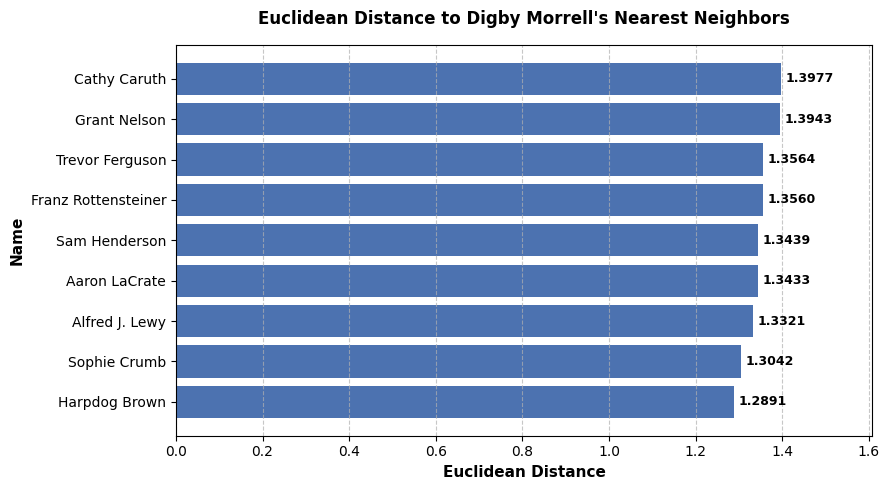

In [70]:
import matplotlib.pyplot as plt
plot_df = results_df[results_df['Rank'] > 0].sort_values(by='Euclidean Distance', ascending=True)

# 2. Create the figure
plt.figure(figsize=(9, 5))
bars = plt.barh(plot_df['Name'], plot_df['Euclidean Distance'], color='#4C72B0')

# 3. Add distance labels on the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
             ha='left', va='center', fontsize=9, fontweight='bold')

# 4. Labels and Title
plt.xlabel('Euclidean Distance', fontsize=11, fontweight='bold')
plt.ylabel('Name', fontsize=11, fontweight='bold')
plt.title("Euclidean Distance to Digby Morrell's Nearest Neighbors", fontsize=12, fontweight='bold', pad=15)

# Adjust x-axis limit to fit text labels cleanly
plt.xlim(0, max(plot_df['Euclidean Distance']) * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [72]:
from sklearn.metrics.pairwise import euclidean_distances

# 1. Choose your list of indices
chosen_indices = [16091, 5705, 3553, 15371, 1258, 747, 4228, 15501, 19844]

# 2. Extract vectors and calculate Euclidean distances
vector_0 = tf_idf[0]
chosen_vectors = tf_idf[chosen_indices]

calc_distances = euclidean_distances(vector_0, chosen_vectors)[0]

# 3. Print results
print("--- Euclidean Distances to Index 0 ---")
for idx, dist in zip(chosen_indices, calc_distances):
    person_name = data.iloc[idx]['name'] if 'data' in globals() else f"Index {idx}"
    print(f"Index {idx:5d} | Distance: {dist:.4f} | Name: {person_name}")

IndexError: index (19844) out of range

In [92]:
distances, indices = nn.kneighbors(
  X = tf_idf[0],
  n_neighbors = 20,
)


ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 20, n_samples_fit = 11, n_samples = 1

## Part 3